# 0. 库函数导入

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import torch
import torch.nn as nn
from torch import optim

import torchvision
show = torchvision.transforms.ToPILImage()

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import concurrent.futures as cf
import multiprocessing as mp
import itertools


# Import utility functions
from my_utils import (
    CIFAR_10_MEAN,
    CIFAR_10_STD,
    CIFAR_10_CLASS,
    FIGURE_DIR,
    get_device,
    get_cifar10_data_augmentation,
    train_model,
    train_experiment,
    evaluate,
    plot_loss_curves,
    plot_task3_hyperparameter_effects,
    count_parameters,
    create_learning_rate_scheduler
)
from my_model import (
    LeNet,
    MyCNN
)

# 1. 数据准备

In [2]:
# Set image normalization transforms and download the dataset
os.makedirs('./dataset', exist_ok=True)

# Get light augmentation for LeNet baseline (only flips + crops).
transform_train_light, transform_test = get_cifar10_data_augmentation(style='light')

# Get full augmentation for modern CNN (Task4) — stored here for later use.
transform_train_full, _ = get_cifar10_data_augmentation(style='full')

BATCH_SIZE = 64

# Load CIFAR-10 with light augmentation for training
full_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_light
)

# Load CIFAR-10 WITHOUT augmentation for validation (clean metrics for early stopping)
full_trainset_clean = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_test
)

# Split into train/val with consistent indices (same split for both datasets)
val_size = int(0.1 * len(full_trainset))
torch.manual_seed(51)
indices = torch.randperm(len(full_trainset)).tolist()
train_indices = indices[val_size:]
val_indices = indices[:val_size]

trainset = torch.utils.data.Subset(full_trainset, train_indices)
valset = torch.utils.data.Subset(full_trainset_clean, val_indices)

print(f"Train set size: {len(trainset)}, Validation set size: {len(valset)}")

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./dataset', train=False, download=True, transform=transform_test
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train set size: 45000, Validation set size: 5000


CIFAR-10 Dataset Statistics
Full training set:  50000 images
  - Training split: 45000 images
  - Validation split: 5000 images
Test set:           10000 images
Image dimensions:   torch.Size([3, 32, 32])
Number of CIFAR_10_CLASS:  10

Class Distribution:
----------------------------------------
  0: plane      5000 images (10.0%)
  1: car        5000 images (10.0%)
  2: bird       5000 images (10.0%)
  3: cat        5000 images (10.0%)
  4: deer       5000 images (10.0%)
  5: dog        5000 images (10.0%)
  6: frog       5000 images (10.0%)
  7: horse      5000 images (10.0%)
  8: ship       5000 images (10.0%)
  9: truck      5000 images (10.0%)


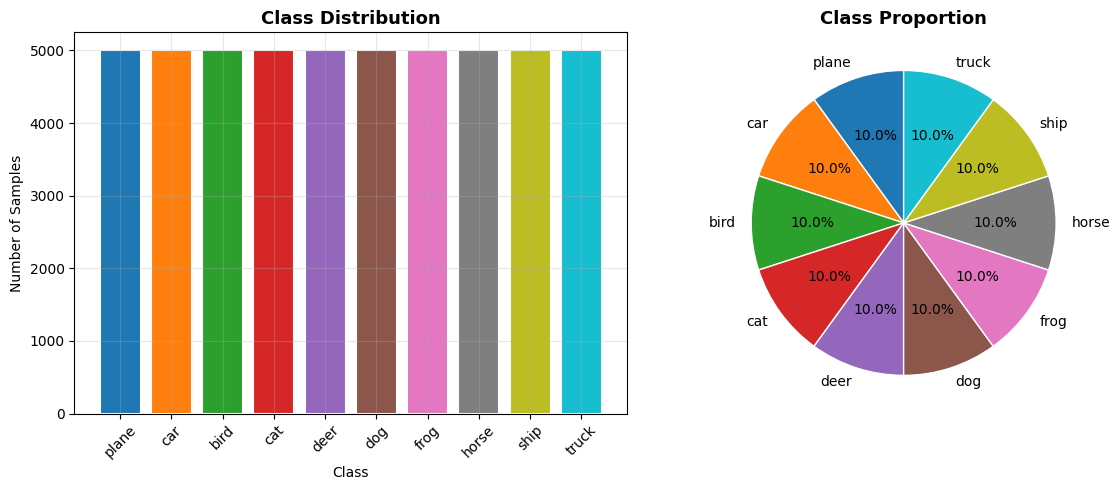

In [3]:
# Data Exploration: Class Distribution and Dataset Statistics
save_path = FIGURE_DIR / 'data_exploration_class_distribution.pdf'

# Collect labels from the full training set
train_labels = [full_trainset[i][1] for i in range(len(full_trainset))]
class_counts = [train_labels.count(i) for i in range(10)]

print("=" * 60)
print("CIFAR-10 Dataset Statistics")
print("=" * 60)
print(f"Full training set:  {len(full_trainset):>5} images")
print(f"  - Training split: {len(trainset):>5} images")
print(f"  - Validation split:{len(valset):>5} images")
print(f"Test set:           {len(testset):>5} images")
print(f"Image dimensions:   {full_trainset[0][0].shape}")
print(f"Number of CIFAR_10_CLASS:  {len(CIFAR_10_CLASS)}")
print()
print("Class Distribution:")
print("-" * 40)
for i, (cls, count) in enumerate(zip(CIFAR_10_CLASS, class_counts)):
    print(f"  {i}: {cls:<8s}  {count:>5} images ({100 * count / len(full_trainset):.1f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.arange(10))

ax1.bar(CIFAR_10_CLASS, class_counts, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.pie(class_counts, labels=CIFAR_10_CLASS, autopct='%1.1f%%', colors=colors,
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


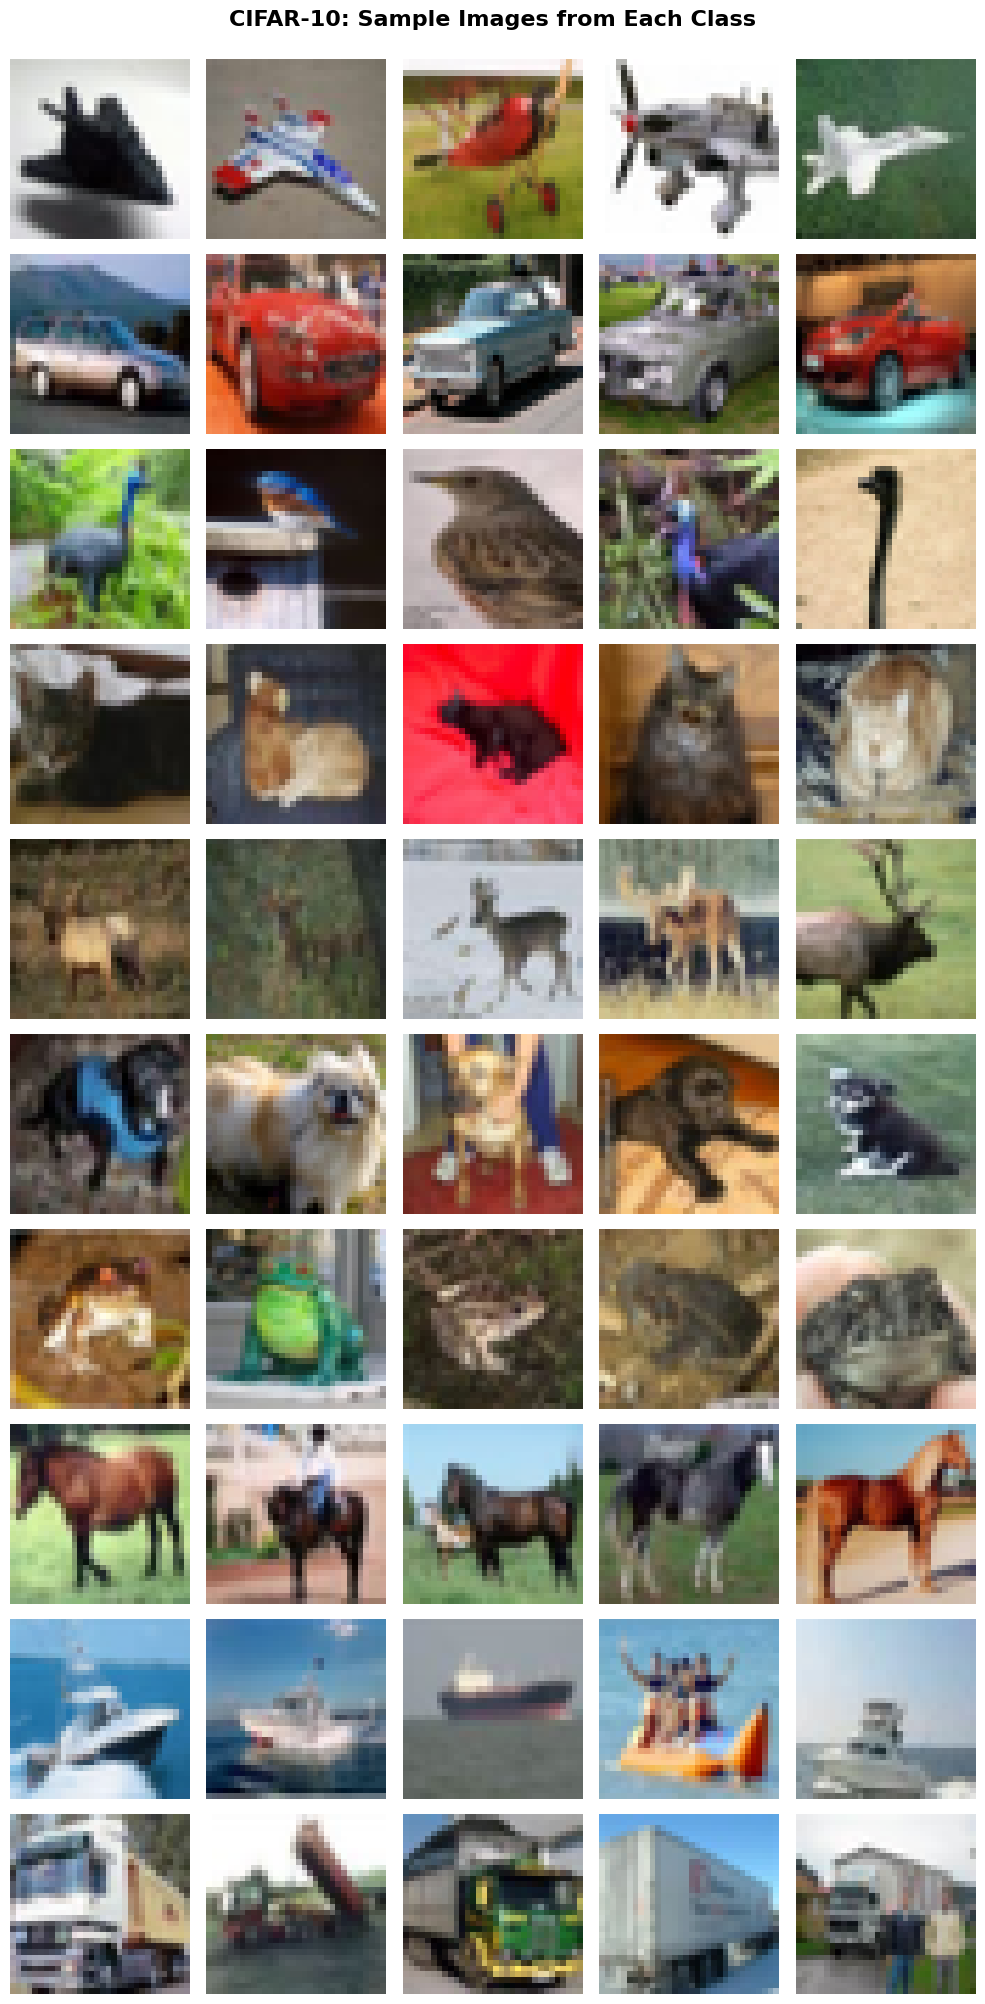

In [4]:
# Data Exploration: Sample Grid from Each Class
save_path = FIGURE_DIR / 'data_exploration_sample_grid.pdf'
samples_per_class = 5

# Load raw training set (without augmentation for clean display)
raw_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR_10_MEAN, CIFAR_10_STD)
    ])
)

# Collect images per class
class_samples = {i: [] for i in range(10)}
for img, label in raw_trainset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# Plot grid: 10 rows (CIFAR_10_CLASS) x 5 columns (samples)
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))
fig.suptitle('CIFAR-10: Sample Images from Each Class', fontsize=16, fontweight='bold', y=1)

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

for i in range(10):
    for j in range(samples_per_class):
        img = class_samples[i][j]
        img_display = img * std_t + mean_t  # Denormalize
        axes[i, j].imshow(img_display.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CIFAR_10_CLASS[i], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Per-Channel Pixel Statistics (raw [0, 1] range)
   Red | Mean: 0.4914 | Std: 0.2470 | Min: 0.0000 | Max: 1.0000
 Green | Mean: 0.4822 | Std: 0.2435 | Min: 0.0000 | Max: 1.0000
  Blue | Mean: 0.4465 | Std: 0.2616 | Min: 0.0000 | Max: 1.0000

Overall   | Mean: 0.4734 | Std: 0.2516


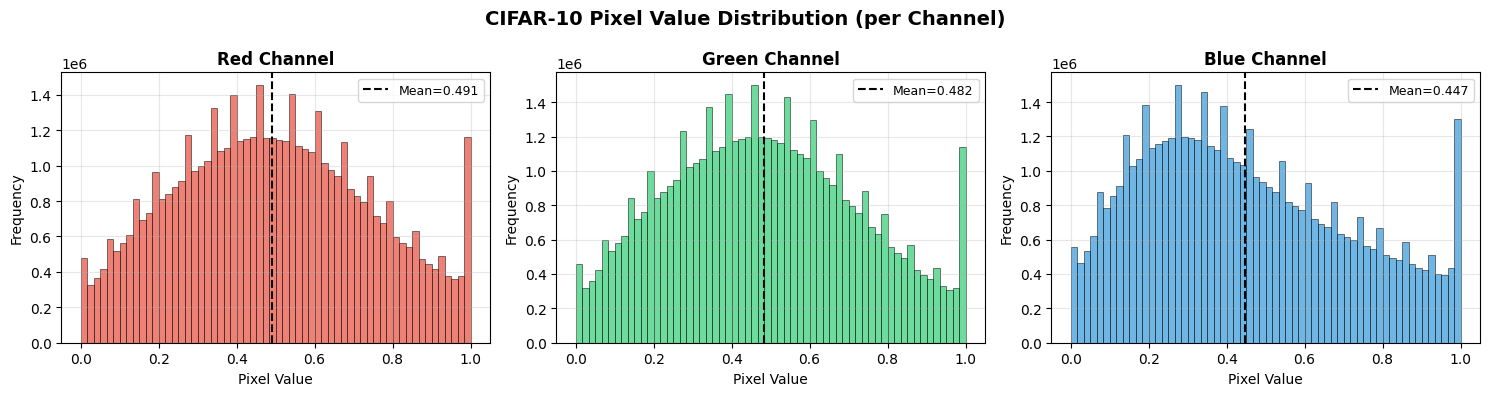

In [5]:
# Data Exploration: Per-Channel Pixel Statistics and Histograms
save_path = FIGURE_DIR / 'data_exploration_pixel_histograms.pdf'
raw_trainset_stats = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.ToTensor()
)

# Stack images
all_pixels = np.stack([np.asarray(raw_trainset_stats[i][0]) for i in range(len(raw_trainset_stats))])

print("=" * 70)
print("Per-Channel Pixel Statistics (raw [0, 1] range)")
print("=" * 70)
channels = ['Red', 'Green', 'Blue']
for i, ch_name in enumerate(channels):
    ch = all_pixels[:, i, :, :]
    print(f"{ch_name:>6} | Mean: {ch.mean():.4f} | Std: {ch.std():.4f} | "
          f"Min: {ch.min():.4f} | Max: {ch.max():.4f}")

print()
print(f"Overall   | Mean: {all_pixels.mean():.4f} | Std: {all_pixels.std():.4f}")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_hist = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ch_name, color) in enumerate(zip(channels, colors_hist)):
    ch_data = all_pixels[:, i, :, :].flatten()
    axes[i].hist(ch_data, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={ch_data.mean():.3f}')
    axes[i].set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 Pixel Value Distribution (per Channel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


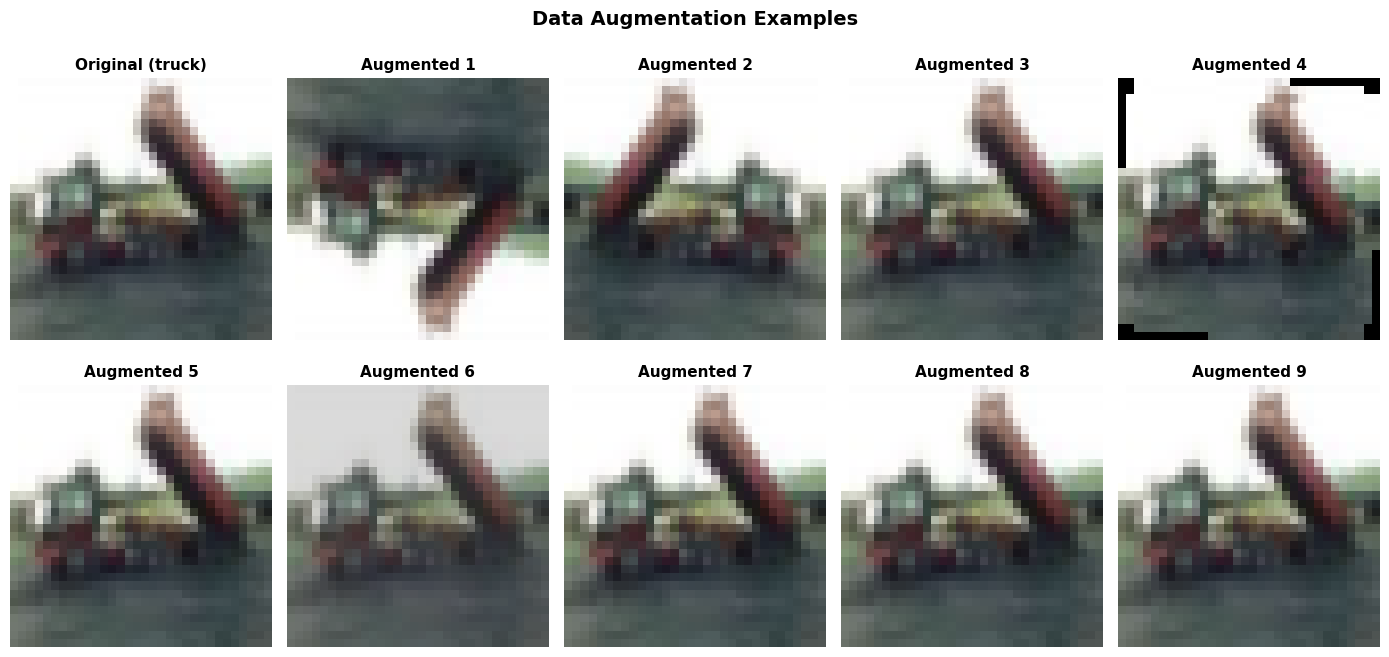

Augmentation visualization saved.
Class: truck


In [6]:
# Data Exploration: Data Augmentation Visualization
# Get a clean PIL image and its label
save_path = FIGURE_DIR / 'data_exploration_augmentation.pdf'
raw_pil_dataset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False
)
sample_img, sample_label = raw_pil_dataset[2]

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes = axes.flatten()

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

# Original image (no augmentation)
axes[0].imshow(np.array(sample_img))
axes[0].set_title(f'Original ({CIFAR_10_CLASS[sample_label]})', fontsize=11, fontweight='bold')
axes[0].axis('off')

# 9 augmented versions using transform_train_full (heavy augmentation for visualization)
for i in range(1, 10):
    aug = transform_train_full(sample_img)
    aug_display = aug * std_t + mean_t  # Denormalize
    axes[i].imshow(aug_display.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i].set_title(f'Augmented {i}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Augmentation visualization saved.\nClass: {CIFAR_10_CLASS[sample_label]}")

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [7]:
lenet_baseline = LeNet(dropout=None)
print(lenet_baseline)

param_counts = count_parameters(lenet_baseline)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


# 3. 模型训练与测试过程
准备好数据、定义好模型后，我们开始训练过程。为了把一个随机初始化的模型优化成一个“好”的模型，我们还需要定义：
- 损失函数$\mathcal{L}$：损失函数以一般同时以模型的预测$\hat{y}$和真实的标签$y$为输入，输出一个标量。这个标量越小，说明模型在数据上拟合得越好。我们的目的就是要最小化这个损失函数$\mathcal{L}(\hat{y},y).$分类问题常使用交叉熵函数作为损失函数。
- 优化方法：为了最小化损失函数，我们就要使用数学的优化方法找到一组最优的参数（这里的参数即神经网络中卷积层、全连接层等的参数，而非batch size等超参数）。深度学习中一般使用迭代的方式求解，常用的方法有SGD（随机梯度下降）、Adam等。
pytorch库内置了各种优化器，我们无需手动实现梯度下降过程。

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [8]:
# Set device (GPU if available)
device = get_device()
print(f"Using device: {device}")

# Move model to device
lenet_baseline = lenet_baseline.to(device)

# --- Shared hyperparameters (used across baseline experiment and Task 2) ---
LR = 1e-3
MIN_LR = LR * 0.1
MOMENTUM = 0.9
NUM_EPOCHS = 128
EARLY_STOPPING_PATIENCE = 10
T_0 = 40
CYCLE_DECAY = 0.5

# --- Baseline experiment ---
LABEL_SMOOTHING = 0.0  # Will be adjusted in Task3

criterion_baseline = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

weight_decay_baseline = 0.0  # No L2 regularization; will be adjusted in Task2
optimizer_baseline = optim.SGD(
    lenet_baseline.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_baseline
)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_baseline})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (linear warm-up + cosine annealing with restarts)
scheduler_config_baseline = create_learning_rate_scheduler(
    optimizer_baseline, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS, 
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0,
    cycle_decay=CYCLE_DECAY
)

# Train the network
save_path_baseline = 'checkpoints/lenet_baseline'
train_losses_baseline, val_accuracies_baseline = train_model(
    model=lenet_baseline,
    train_loader=train_loader,
    criterion=criterion_baseline,
    optimizer=optimizer_baseline,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_baseline,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_baseline
)

print(f"Final training loss: {train_losses_baseline[-1]:.4f}")
if val_accuracies_baseline:
    print(f"Final validation accuracy: {val_accuracies_baseline[-1]:.2f}%")

Using GPU: NVIDIA GeForce RTX 4090
Using device: cuda:0
Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=0.0)
Epochs: 128 (with early stopping)
Created CosineAnnealingWarmRestartsDecay (T_0=40, T_mult=2, cycle_decay=0.5)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 128
Training on device: cuda:0
Initial training loss (before training): 2.3213
Initial validation accuracy (before training): 9.20%
--------------------------------------------------
Epoch 1/128: Train Loss: 2.3032, Val Accuracy: 12.04%, Learning Rate: 0.000200, Grad Norm: 0.1978
  -> New best model saved with accuracy: 12.04%
Epoch 2/128: Train Loss: 2.2965, Val Accuracy: 13.30%, Learning Rate: 0.000400, Grad Norm: 0.2254
  -> New best model saved with accuracy: 13.30%
Epoch 3/128: Train Loss: 2.2186, Val Accuracy: 23.40%, Learning Rate: 0.000600, Grad Norm: 0.5580
  -> New best model saved with accuracy: 23.40%
Epoch 4/128: Train Loss: 1.

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [9]:
# Evaluate on test set
print("\nEvaluating LeNet baseline on test set...")
test_result_baseline = evaluate(
    model=lenet_baseline, test_loader=test_loader, device=device,
    model_name='lenet_baseline', save_plots=True,
)
test_accuracy_baseline = test_result_baseline['accuracy']

# Results comparison
print("\n=== Baseline Results ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_baseline):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_baseline[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_baseline:.2f}%")
print(f"  - ECE (calibration error):    {test_result_baseline['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_baseline['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_baseline['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")


Evaluating LeNet baseline on test set...

Comprehensive Evaluation — lenet_baseline

──────────────────────────────────────────────────────────────────────
  Accuracy:                       58.89%
  Average F1:                     0.5864
  ECE (calibration error):        0.0115
  Pred distribution KL:            0.004939
──────────────────────────────────────────────────────────────────────


=== Baseline Results ===
  - Best validation accuracy:   58.24%
  - Final validation accuracy:  57.94%
  - Test accuracy:              58.89%
  - ECE (calibration error):    0.0115
  - Pred distribution KL:       0.004939
  - Best F1:      ship = 0.7059
  - Worst F1:      cat = 0.4019



# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

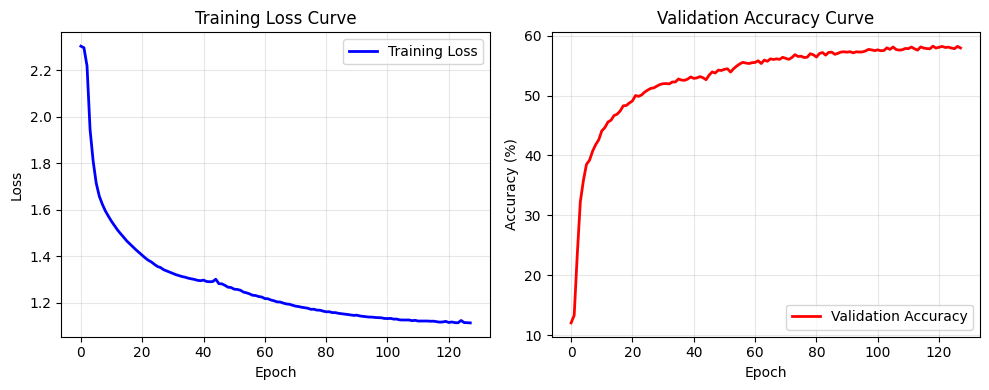

Loss curve saved to figures/lenet_baseline_loss_curve.pdf
Final training loss: 1.1127
Final validation accuracy: 57.94%


In [10]:
# Plot loss curves using utility function
plot_loss_curves(train_losses_baseline, val_accuracies_baseline, FIGURE_DIR / 'lenet_baseline_loss_curve.pdf')

In [11]:
# Clean up GPU memory
del lenet_baseline, optimizer_baseline, criterion_baseline, scheduler_config_baseline
del train_losses_baseline, val_accuracies_baseline
torch.cuda.empty_cache()

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [12]:
# Instantiate LeNet with dropout for Task3 experiments
lenet_dropout = LeNet(dropout=0.2)
print(lenet_dropout)

param_counts = count_parameters(lenet_dropout)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


In [13]:
# Task2: Train model with Dropout + L2 regularization
# Move model to device
lenet_dropout = lenet_dropout.to(device)

# Dropout experiment: L2 regularization via weight_decay
weight_decay_dropout = 1e-5
optimizer_dropout = optim.SGD(
    lenet_dropout.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_dropout
)
criterion_dropout = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_dropout})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (separate instance for this optimizer)
scheduler_config_dropout = create_learning_rate_scheduler(
    optimizer_dropout, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0,
    cycle_decay=CYCLE_DECAY
)

# Train Dropout network with L2 regularization
save_path_dropout = 'checkpoints/lenet_dropout'
train_losses_dropout, val_accuracies_dropout = train_model(
    model=lenet_dropout,
    train_loader=train_loader,
    criterion=criterion_dropout,
    optimizer=optimizer_dropout,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_dropout,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_dropout
)

# Plot loss curves
plot_loss_curves(train_losses_dropout, val_accuracies_dropout, FIGURE_DIR / 'lenet_dropout_loss_curve.pdf')

Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=1e-05)
Epochs: 128 (with early stopping)
Created CosineAnnealingWarmRestartsDecay (T_0=40, T_mult=2, cycle_decay=0.5)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 128
Training on device: cuda:0
Initial training loss (before training): 2.2906
Initial validation accuracy (before training): 9.88%
--------------------------------------------------
Epoch 1/128: Train Loss: 2.2959, Val Accuracy: 16.54%, Learning Rate: 0.000200, Grad Norm: 0.2429
  -> New best model saved with accuracy: 16.54%
Epoch 2/128: Train Loss: 2.2442, Val Accuracy: 18.30%, Learning Rate: 0.000400, Grad Norm: 0.4531
  -> New best model saved with accuracy: 18.30%


KeyboardInterrupt: 

In [ ]:
# Evaluate on test set
print("\nEvaluating LeNet with Dropout on test set...")
test_result_dropout = evaluate(
    model=lenet_dropout, 
    test_loader=test_loader, 
    device=device,
    model_name='lenet_dropout', 
    save_plots=True
)
test_accuracy_dropout = test_result_dropout['accuracy']

# Results comparison
print("\n=== Task2 Results: Dropout + L2 Regularization ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_dropout):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_dropout[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_dropout:.2f}%")
print(f"  - ECE (calibration error):    {test_result_dropout['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_dropout['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_dropout['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (LeNet with dropout enables this)
if test_result_dropout.get('mc_dropout'):
    md = test_result_dropout['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating LeNet with Dropout on test set...

Comprehensive Evaluation — lenet_dropout

[MC Dropout] Evaluating uncertainty ...

──────────────────────────────────────────────────────────────────────
  Accuracy:                       61.87%
  Average F1:                     0.6130
  ECE (calibration error):        0.0293
  Pred distribution KL:            0.011564
  MC Dropout (20 samples):
    Avg predictive variance:      0.010348
    Accurate variance (mean):     0.010243
    Inaccurate variance (mean):   0.010518
──────────────────────────────────────────────────────────────────────


=== Task2 Results: Dropout + L2 Regularization ===
  - Best validation accuracy:   62.02%
  - Final validation accuracy:  62.02%
  - Test accuracy:              61.87%
  - ECE (calibration error):    0.0293
  - Pred distribution KL:       0.011564
  - Best F1:       car = 0.7320
  - Worst F1:      cat = 0.3940

MC Dropout Uncertainty:
  - Avg predictive variance:       0.010348
  - Accurate variance 

In [ ]:
# Clean up GPU memory
del lenet_dropout, optimizer_dropout, criterion_dropout, scheduler_config_dropout
del train_losses_dropout, val_accuracies_dropout
torch.cuda.empty_cache()

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。

In [ ]:
# Task3: Hyperparameter Tuning Experiments (3x3x3x3 grid, 81 experiments)
# Parallel execution with MAX_WORKERS concurrent worker processes.
MAX_WORKERS = 16
DROPOUT = None

# Hyperparameter grid
LR_GRID = [5e-4, 1e-3, 2e-3]
WD_GRID = [0, 1e-5, 2e-5]
LS_GRID = [0, 1e-2, 2e-2]
BS_GRID = [16, 32, 64]
# All Task3 experiments use LeNet without dropout for consistent comparison
NUM_EXPERIMENTS = len(LR_GRID) * len(WD_GRID) * len(LS_GRID) * len(BS_GRID)

print("=" * 70)
print("Task3: Hyperparameter Tuning Experiments (Parallel, LeNet + Dropout)")
print(f"  lr           = {LR_GRID}")
print(f"  weight_decay = {WD_GRID}")
print(f"  label_smooth = {LS_GRID}")
print(f"  batch_size   = {BS_GRID}")
print(f"  Total: {NUM_EXPERIMENTS} experiments x {NUM_EPOCHS} epochs each")
print(f"  Workers: {MAX_WORKERS} concurrent on GPU")
print("=" * 70)

# Create output directories
LOG_DIR = Path('logs/task3')
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('checkpoints/task3')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Prepare argument list for all experiments.
# train_indices / val_indices are the lists from the data-prep cell above.
experiment_args = []
for exp_idx, (lr, wd, ls, bs) in enumerate(
    itertools.product(LR_GRID, WD_GRID, LS_GRID, BS_GRID), 1
):
    experiment_args.append((
        exp_idx, DROPOUT, lr, wd, ls, bs,
        train_indices, val_indices,
        NUM_EPOCHS, T_0, CYCLE_DECAY, 
        str(CKPT_DIR), str(LOG_DIR)
    ))

results = []

# Use spawn context for safe CUDA multiprocessing
ctx = mp.get_context('spawn')

print(f"\nStarting parallel execution with {MAX_WORKERS} workers...")
print(f"Multiprocessing context: {ctx.get_start_method()}\n")

with cf.ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=ctx) as executor:
    # Submit all experiments to the pool
    future_map = {
        executor.submit(train_experiment, *args): args
        for args in experiment_args
    }

    # Collect results as they complete
    for future in cf.as_completed(future_map):
        args = future_map[future]
        exp_idx = args[0]
        try:
            result = future.result()
            results.append(result)
            print(f"[{result['experiment_id']:02d}/{NUM_EXPERIMENTS}] "
                  f"lr={result['learning_rate']}, wd={result['weight_decay']}, "
                  f"ls={result['label_smoothing']}, bs={result['batch_size']} | "
                  f"val_acc={result['best_val_accuracy']:.2f}%, "
                  f"test_acc={result['test_accuracy']:.2f}%, "
                  f"epochs={result['epochs_trained']}")
        except Exception as e:
            print(f"[{exp_idx:02d}/{NUM_EXPERIMENTS}] FAILED: {e}")

# Sort by experiment_id for consistent ordering
results.sort(key=lambda r: r['experiment_id'])

Task3: Hyperparameter Tuning Experiments (Parallel, LeNet + Dropout)
  lr           = [0.0005, 0.001, 0.002]
  weight_decay = [0, 1e-05, 2e-05]
  label_smooth = [0, 0.05]
  batch_size   = [16, 64]
  Total: 36 experiments x 160 epochs each
  Workers: 16 concurrent on GPU

Starting parallel execution with 16 workers...
Multiprocessing context: spawn



Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090


/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using GPU: NVIDIA GeForce RTX 4090
Using GPU: NVIDIA GeForce RTX 4090


/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


...

Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[26/36] lr=0.002, wd=0, ls=0, bs=64 | val_acc=66.12%, test_acc=65.81%, epochs=24
Using GPU: NVIDIA GeForce RTX 4090


/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[25/36] lr=0.002, wd=0, ls=0, bs=16 | val_acc=66.28%, test_acc=64.68%, epochs=24
Using GPU: NVIDIA GeForce RTX 4090


/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.002
  Min LR: 1e-06, Total epochs: 160
[18/36] lr=0.001, wd=1e-05, ls=0, bs=64 | val_acc=68.26%, test_acc=66.78%, epochs=44
[28/36] lr=0.002, wd=0, ls=0.05, bs=64 | val_acc=65.64%, test_acc=64.57%, epochs=24
[27/36] lr=0.002, wd=0, ls=0.05, bs=16 | val_acc=66.48%, test_acc=62.64%, epochs=23
[29/36] lr=0.002, wd=1e-05, ls=0, bs=16 | val_acc=68.88%, test_acc=66.95%, epochs=24
[31/36] lr=0.002, wd=1e-05, ls=0.05, bs=16 | val_acc=68.50%, test_acc=65.68%, epochs=24
[20/36] lr=0.001, wd=1e-05, ls=0.05, bs=64 | val_acc=68.36%, test_acc=67.12%, epochs=40
[08/36] lr=0.0005, wd=1e-05, ls=0.05, bs=64 | val_acc=68.26%, test_acc=66.92%, epochs=83
[22/36] lr=0.001, wd=2e-05, ls=0, bs=64 | val_acc=66.96%, test_acc=65.20%, epochs=42
[24/36] lr=0.001, wd=2e-05, ls=0.05, bs=64 | val_acc=66.74%, test_acc=65.06%, epochs=42
[21/36] lr=0.001, wd=2e-05, ls=0, bs=16 | val_acc=69.06%, test_acc=66.88%, epochs=43
[30/36] 


Hyperparameter Tuning Results (sorted by test_accuracy):
 experiment_id  learning_rate  weight_decay  label_smoothing  batch_size  best_val_accuracy  test_accuracy  final_train_loss  epochs_trained optimizer                                           log_file
            17         0.0010       0.00001             0.00          16              69.56          67.39          0.798530              23      Adam     logs/task3/exp_17_lr0.001_wd1e-05_ls0_bs16.log
             3         0.0005       0.00000             0.05          16              68.64          67.26          0.947783              44      Adam     logs/task3/exp_03_lr0.0005_wd0_ls0.05_bs16.log
            20         0.0010       0.00001             0.05          64              68.36          67.12          1.003193              40      Adam  logs/task3/exp_20_lr0.001_wd1e-05_ls0.05_bs64.log
            11         0.0005       0.00002             0.05          16              68.08          66.99          0.984676          

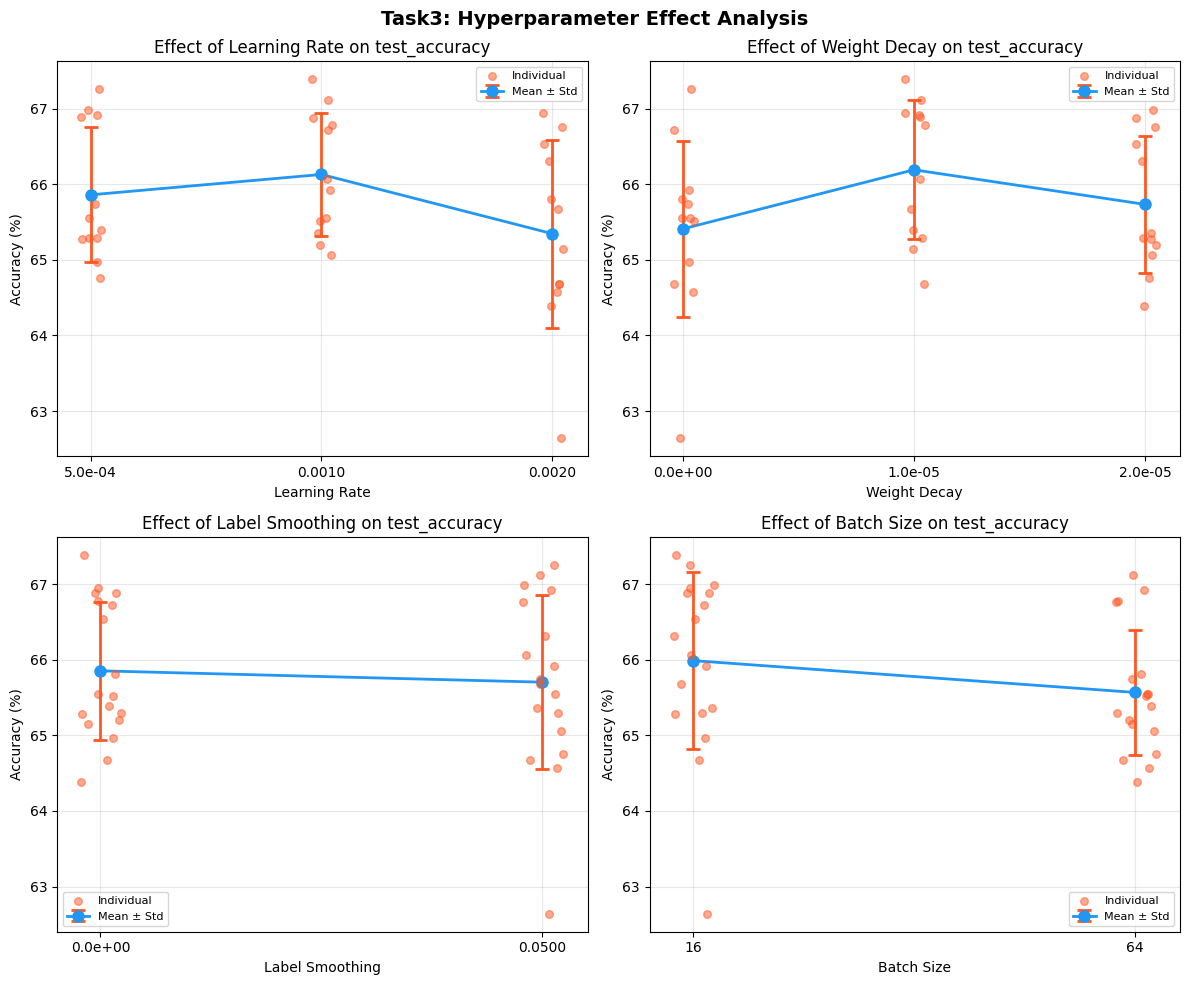

Saved: figures/task3_hyperparameter_effects.pdf

Best Hyperparameter Combination (by test accuracy):
  experiment_id: 17
  learning_rate: 0.001
  weight_decay: 1e-05
  label_smoothing: 0.0
  batch_size: 16
  best_val_accuracy: 69.56
  test_accuracy: 67.39
  final_train_loss: 0.798529741118228
  epochs_trained: 23
  optimizer: Adam
  log_file: logs/task3/exp_17_lr0.001_wd1e-05_ls0_bs16.log


In [ ]:
# --- Results summary ---
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Hyperparameter Tuning Results (sorted by test_accuracy):")
print("=" * 70)
print(results_df.sort_values('test_accuracy', ascending=False).to_string(index=False))

# Save to CSV
results_df.to_csv('task3_hyperparameter_results.csv', index=False)
print(f"\nResults saved to 'task3_hyperparameter_results.csv'")
print(f"Full logs saved to {LOG_DIR}/")

# --- Comprehensive Visualization ---
# Line charts showing systematic effect of each hyperparameter on test accuracy
plot_task3_hyperparameter_effects(
    results_df,
    save_dir='figures',
    figure_prefix='task3',
    metric='test_accuracy',
)

# --- Best combination (by test_accuracy) ---
best = results_df.loc[results_df['test_accuracy'].idxmax()]
print("\n" + "=" * 70)
print("Best Hyperparameter Combination (by test accuracy):")
print("=" * 70)
for col in results_df.columns:
    print(f"  {col}: {best[col]}")
print("=" * 70)

# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [ ]:
# Instantiate MyCNN
mycnn = MyCNN(num_classes=len(CIFAR_10_CLASS), dropout_rate=None)
print(mycnn)

param_counts = count_parameters(mycnn)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

MyCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


/root/snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loss function: CrossEntropyLoss (label_smoothing=0.05)
Optimizer: Adam (lr=2e-05, weight_decay=1e-05)
Epochs: 320 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 2e-05
  Min LR: 2.0000000000000003e-06, Total epochs: 320
Training on device: cuda:0
Initial training loss (before training): 2.3075
Initial validation accuracy (before training): 9.06%
--------------------------------------------------
Epoch 1/320: Train Loss: 2.0829, Val Accuracy: 34.02%, Learning Rate: 0.000004, Grad Norm: 10.4941
  -> New best model saved with accuracy: 34.02%
Epoch 2/320: Train Loss: 1.8606, Val Accuracy: 40.02%, Learning Rate: 0.000008, Grad Norm: 12.2824
  -> New best model saved with accuracy: 40.02%
Epoch 3/320: Train Loss: 1.7578, Val Accuracy: 46.40%, Learning Rate: 0.000012, Grad Norm: 12.9821
  -> New best model saved with accuracy: 46.40%
Epoch 4/320: Train Loss: 1.6738, Val Accuracy: 50.56%, Learning Rate: 0.000016, Grad Norm: 13.04

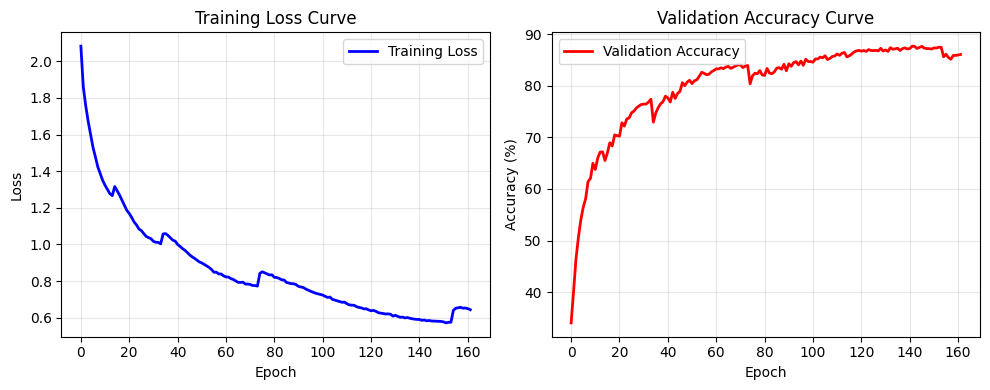

Loss curve saved to figures/mycnn_loss_curve.pdf
Final training loss: 0.6434
Final validation accuracy: 86.08%


In [ ]:
# Task4: MyCNN
# Create DataLoader with full augmentation for modern CNN
BATCH_SIZE = 128
full_trainset_full_aug = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_full
)
trainset_full_aug = torch.utils.data.Subset(full_trainset_full_aug, train_indices)
train_loader_full_aug = torch.utils.data.DataLoader(
    trainset_full_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

# Move model to device
mycnn = mycnn.to(device)

# Configure optimizer and loss
LR_MYCNN = 5e-4
MIN_LR_MYCNN = LR_MYCNN * 0.1
WEIGHT_DECAY_MYCNN = 1e-5
LABEL_SMOOTHING_MYCNN = 0.05
NUM_EPOCHS = 256
EARLY_STOPPING_PATIENCE = 20
T_0 = 80
CYCLE_DECAY = 0.5

criterion_mycnn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING_MYCNN)
optimizer_mycnn = optim.Adam(mycnn.parameters(), lr=LR_MYCNN, weight_decay=WEIGHT_DECAY_MYCNN)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING_MYCNN})")
print(f"Optimizer: Adam (lr={LR_MYCNN}, weight_decay={WEIGHT_DECAY_MYCNN})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create LR scheduler
scheduler_config_mycnn = create_learning_rate_scheduler(
    optimizer_mycnn,
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR_MYCNN,
    min_lr=MIN_LR_MYCNN,
    T_0=T_0,
    cycle_decay=CYCLE_DECAY
)

# Train
save_path_mycnn = 'checkpoints/mycnn'
train_losses_mycnn, val_accuracies_mycnn = train_model(
    model=mycnn,
    train_loader=train_loader_full_aug,
    criterion=criterion_mycnn,
    optimizer=optimizer_mycnn,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_mycnn,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_mycnn
)

print(f"Final training loss: {train_losses_mycnn[-1]:.4f}")
if val_accuracies_mycnn:
    print(f"Final validation accuracy: {val_accuracies_mycnn[-1]:.2f}%")

# Plot loss curves
plot_loss_curves(train_losses_mycnn, val_accuracies_mycnn, FIGURE_DIR / 'mycnn_loss_curve.pdf')

In [ ]:
# Evaluate on test set
print("\nEvaluating MyCNN on test set...")
test_result_mycnn = evaluate(
    model=mycnn, 
    test_loader=test_loader, 
    device=device,
    model_name='mycnn', 
    save_plots=True
)
test_accuracy_mycnn = test_result_mycnn['accuracy']

# Safely retrieve training history (may vary across runs)
best_val_acc = max(val_accuracies_mycnn)
final_val_acc = val_accuracies_mycnn[-1]
epochs_done = len(train_losses_mycnn)

# Comparison with baseline model
print("\n" + "="*70)
print("Task4 Results:")
print("="*70)
print("MyCNN:")
print(f"  - Best validation accuracy:   {best_val_acc}")
print(f"  - Final validation accuracy:  {final_val_acc}")
print(f"  - Test accuracy:              {test_accuracy_mycnn:.2f}%")
print(f"  - ECE (calibration error):    {test_result_mycnn['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_mycnn['pred_dist_kl']:.6f}")
print(f"  - Epochs trained:             {epochs_done}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_mycnn['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (MyCNN has dropout)
if test_result_mycnn.get('mc_dropout'):
    md = test_result_mycnn['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating MyCNN on test set...

Comprehensive Evaluation — mycnn

[MC Dropout] Evaluating uncertainty ...

──────────────────────────────────────────────────────────────────────
  Accuracy:                       87.24%
  Average F1:                     0.8712
  ECE (calibration error):        0.0173
  Pred distribution KL:            0.005724
  MC Dropout (20 samples):
    Avg predictive variance:      0.000855
    Accurate variance (mean):     0.000615
    Inaccurate variance (mean):   0.002488
──────────────────────────────────────────────────────────────────────


Task4 Results:
MyCNN:
  - Best validation accuracy:   89.48
  - Final validation accuracy:  87.68
  - Test accuracy:              87.24%
  - ECE (calibration error):    0.0173
  - Pred distribution KL:       0.005724
  - Epochs trained:             92
  - Best F1:       car = 0.9454
  - Worst F1:      cat = 0.7160

MC Dropout Uncertainty:
  - Avg predictive variance:E       0.000855
  - Accurate variance (mean):      0.0

In [ ]:
# Clean up GPU memory
del mycnn, optimizer_mycnn, criterion_mycnn, scheduler_config_mycnn
del train_losses_mycnn, val_accuracies_mycnn, param_counts
torch.cuda.empty_cache()